In [74]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [75]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [76]:
modeApi = lumapi.MODE(hide = False)

#units

um = 1e-6
nm = 1e-9

## Specifying the device and solver characteristics ##

In [77]:
#Device dimensions

gap = 200*nm
wvg_height = 220*nm
wvg1_width = 450*nm
wvg2_width = 940*nm
Ldc = 5*um
rad = 10*um

#Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

#Solver dimensions and parameters
y_span_solver = 3*(gap + wvg1_width + wvg2_width)
z_span_solver = 5*wvg_height

bc = 'PML'
wavelength = 1.55*um
start_wavelength = 1.5*um
stop_wavelength = 1.6*um
mesh_cells = 200
solver_type = '2D X normal'

#mesh dimensions and parameters

z_span_mesh = wvg_height
mesh_multiplier = 3

## Building the device ##

In [78]:
modeApi.addrect()
modeApi.set('name', 'wvg_1')
modeApi.set('x', 0)
modeApi.set('x span', Ldc)
modeApi.set('y min', gap/2)
modeApi.set('y max', gap/2 + wvg1_width)
modeApi.set('z', 0)
modeApi.set('z span', wvg_height)
modeApi.set('material', material)

modeApi.addrect()
modeApi.set('name', 'wvg_2')
modeApi.set('x', 0)
modeApi.set('x span', Ldc + 2*rad)
modeApi.set('y max', -gap/2)
modeApi.set('y min', -(gap/2 + wvg2_width))
modeApi.set('z', 0)
modeApi.set('z span', wvg_height)
modeApi.set('material', material)

modeApi.addobject('90_bend_wg')
modeApi.set('name', '90_bend_1')
modeApi.set('radius', rad)
modeApi.set('base height', wvg_height)
modeApi.set('base width', wvg1_width)
modeApi.set('x', Ldc/2)
modeApi.set('y', rad+(gap+wvg1_width)/2)
modeApi.set('z', 0)
modeApi.set('first axis', 'x')
modeApi.set('rotation 1', 180)
modeApi.set('material', material)

modeApi.addobject('90_bend_wg')
modeApi.set('name', '90_bend_2')
modeApi.set('radius', rad)
modeApi.set('base height', wvg_height)
modeApi.set('base width', wvg1_width)
modeApi.set('x', -Ldc/2)
modeApi.set('y', rad+(gap+wvg1_width)/2)
modeApi.set('z', 0)
modeApi.set('first axis', 'x')
modeApi.set('second axis', 'y')
modeApi.set('rotation 1', 180)
modeApi.set('rotation 2', 180)
modeApi.set('material', material)

#add solver

modeApi.addfde()
modeApi.set('solver type', solver_type)
modeApi.set('x', 0)
modeApi.set('y', 0)
modeApi.set('y span', y_span_solver)
modeApi.set('z', 0)
modeApi.set('z span', z_span_solver)
modeApi.set('y min bc', bc)
modeApi.set('y max bc', bc)
modeApi.set('z min bc', bc)
modeApi.set('z max bc', bc)
modeApi.set('define y mesh by', 'number of mesh cells')
modeApi.set('define z mesh by', 'number of mesh cells')
modeApi.set('mesh cells y', mesh_cells)
modeApi.set('mesh cells z', mesh_cells)
modeApi.set('wavelength', wavelength)
modeApi.set('number of trial modes', 4)
modeApi.set('fit materials with multi-coefficient model', True)
modeApi.set('wavelength start', start_wavelength)
modeApi.set('wavelength stop', stop_wavelength)
modeApi.set('background material', sub_material)

#add mesh

modeApi.addmesh()
modeApi.set('set mesh multiplier', True)
modeApi.set('x', 0)
modeApi.set('x span', 0)
modeApi.set('y min', -(gap/2 + wvg2_width))
modeApi.set('y max', gap/2 + wvg1_width)
modeApi.set('z', 0)
modeApi.set('z span', z_span_mesh)
modeApi.set('y mesh multiplier', mesh_multiplier)
modeApi.set('z mesh multiplier', mesh_multiplier)

modeApi.save('Conversor_DC_FDE')

### Visualizing a cross-section of the device in the central region ###

In [79]:
modeApi.findmodes()

4.0

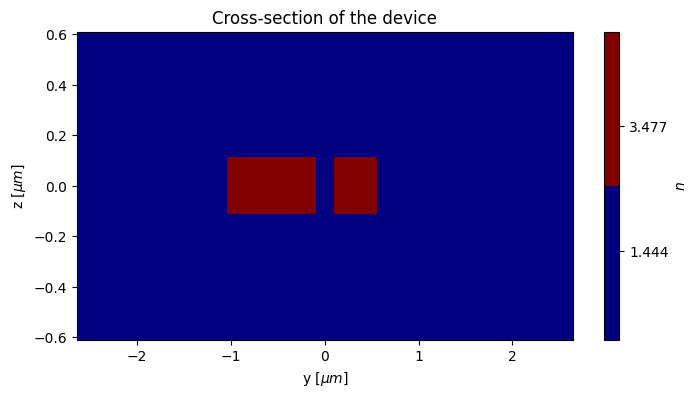

In [80]:
index_x = np.squeeze(modeApi.getdata('FDE::data::material', 'index_x'))
y_structure = np.squeeze(modeApi.getdata('FDE::data::material', 'y'))/um
z_structure = np.squeeze(modeApi.getdata('FDE::data::material', 'z'))/um

Y, Z = np.meshgrid(y_structure, z_structure)
v = np.linspace(np.min(index_x), np.max(index_x), 2)

im = plt.contourf(Y, Z, np.rot90(index_x), 0, cmap = plt.get_cmap('jet'), vmin = v[0], vmax = v[-1], origin = 'lower')
colorbar = plt.colorbar(im, label = r'$n$')
colorbar.set_ticks(v)
plt.xlabel(r'y [$\mu m$]')
plt.ylabel(r'z [$\mu m$]')
plt.title('Cross-section of the device')
plt.show()

## Visualizing the two first supermodes ##

In [81]:
eField_1 = np.squeeze(modeApi.getresult('FDE::data::mode1', 'Ey'))
y_eField = modeApi.getresult('FDE::data::mode1', 'y')/um
z_eField = modeApi.getresult('FDE::data::mode1', 'z')/um
n1 = (modeApi.getresult('FDE::data::mode1', 'neff').real)[0,0]

rfIndex = np.squeeze(modeApi.getresult('FDE::data::material', 'index_y'))

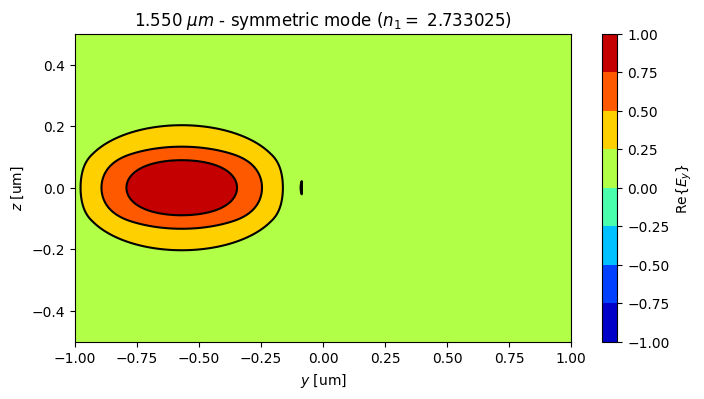

In [82]:
v = np.linspace(-1, 1, 9)

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)
Y, Z = np.meshgrid(y_eField, z_eField)
plt.contourf(Y, Z, np.rot90(rfIndex.real), 0, colors = 'gray', origin = 'lower')
plt.contour(Y, Z, np.rot90(eField_1.real), v, colors = 'k', vmin = -1, vmax = 1)
im = plt.contourf(Y, Z, np.rot90(eField_1.real), v, cmap = plt.cm.jet, vmin = -1, vmax = 1)

colorbar = plt.colorbar(im)
colorbar.set_ticks(v)
colorbar.set_label(r'$\mathrm{Re}\{E_y\}$')

plt.xlabel(r'$y$ ' + r'$\mathrm{[um]}$')
plt.ylabel(r'$z$ ' + r'$ \mathrm{[um]}$')
plt.xlim(-1, 1)
plt.ylim(-0.5, 0.5)

plt.title(r'%4.3f $\mu m$ - symmetric mode ($n_1 =$ %.6f)' %(wavelength/um, n1))
plt.show()

In [83]:
eField_2 = np.squeeze(modeApi.getresult('FDE::data::mode2', 'Ey'))
y_eField = modeApi.getresult('FDE::data::mode2', 'y')/um
z_eField = modeApi.getresult('FDE::data::mode2', 'z')/um
n2 = (modeApi.getresult('FDE::data::mode2', 'neff').real)[0,0]

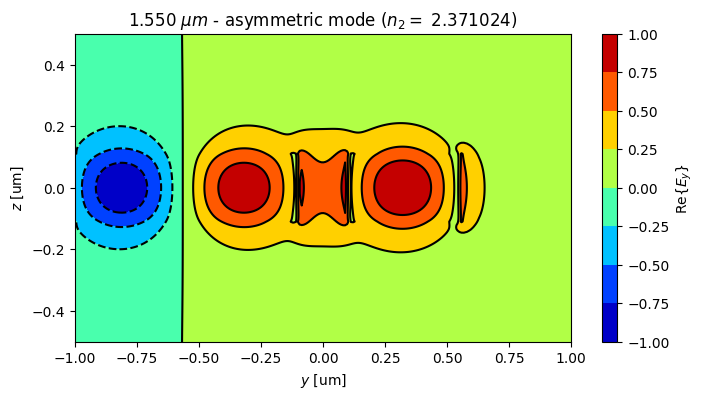

In [84]:
v = np.linspace(-1, 1, 9)

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)
Y, Z = np.meshgrid(y_eField, z_eField)
plt.contourf(Y, Z, np.rot90(rfIndex.real), 0, colors = 'gray', origin = 'lower')
plt.contour(Y, Z, np.rot90(eField_2.real), v, colors = 'k', vmin = -1, vmax = 1)
im = plt.contourf(Y, Z, np.rot90(eField_2.real), v, cmap = plt.cm.jet, vmin = -1, vmax = 1)

colorbar = plt.colorbar(im)
colorbar.set_ticks(v)
colorbar.set_label(r'$\mathrm{Re}\{E_y\}$')

plt.xlabel(r'$y$ ' + r'$\mathrm{[um]}$')
plt.ylabel(r'$z$ ' + r'$ \mathrm{[um]}$')
plt.xlim(-1, 1)
plt.ylim(-0.5, 0.5)

plt.title(r'%4.3f $\mu m$ - asymmetric mode ($n_2 =$ %.6f)' %(wavelength/um, n2))
plt.show()

In [86]:
modeApi.close()